# 🎣 Phishing Website Detection: ML for Cybersecurity

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Detecting phishing websites from URL and page features to protect government networks and citizens  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for detecting phishing websites using URL structural features, page characteristics, and web reputation metrics. The model supports **real-time URL screening** for government network protection and citizen safety.

### Government Policy Context
- **ASD (Australian Signals Directorate)** — Essential Eight mitigation strategies, ACSC threat advisories
- **Home Affairs** — Critical Infrastructure Security Act, cyber incident reporting
- **DTA (Digital Transformation Agency)** — Whole-of-government cyber hygiene, myGov protection
- **ACSC (Australian Cyber Security Centre)** — ReportCyber platform, phishing campaign tracking
- **OAIC (Office of the Australian Information Commissioner)** — Notifiable data breaches from phishing

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Phishing (high confidence) | Block URL, alert SOC, update threat intelligence | SOC + network ops |
| Phishing (borderline) | Sandbox for analysis, warn user with interstitial | Web proxy |
| Legitimate (confident) | Allow access, routine logging | Automated gateway |
| Legitimate (low confidence) | Allow with enhanced monitoring | SIEM alerting |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/shashwatwork/web-page-phishing-detection-dataset/dataset_phishing.csv

Loaded: 11,430 rows x 89 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    print(f"  {i:2d}. {col:40s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d}")
print(f"\nTotal columns: {len(df.columns)}")
df.head()


COLUMN SUMMARY
   0. url                                      | object     | unique= 11429 | nulls=  0
   1. length_url                               | int64      | unique=   324 | nulls=  0
   2. length_hostname                          | int64      | unique=    83 | nulls=  0
   3. ip                                       | int64      | unique=     2 | nulls=  0
   4. nb_dots                                  | int64      | unique=    19 | nulls=  0
   5. nb_hyphens                               | int64      | unique=    27 | nulls=  0
   6. nb_at                                    | int64      | unique=     5 | nulls=  0
   7. nb_qm                                    | int64      | unique=     4 | nulls=  0
   8. nb_and                                   | int64      | unique=    15 | nulls=  0
   9. nb_or                                    | int64      | unique=     1 | nulls=  0
  10. nb_eq                                    | int64      | unique=    16 | nulls=  0
  11. nb_undersco

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['status', 'label', 'Label', 'phishing', 'Phishing', 'CLASS_LABEL',
                     'class', 'Class', 'Target', 'target', 'Result', 'type', 'Type']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

if df[target_col].dtype == 'object':
    phishing_kw = ['phishing', 'Phishing', 'spam', 'Spam', 'malicious', '1', 'bad', 'unsafe']
    mapping = {v: (1 if v in phishing_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'status'

Raw values:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64
Mapped: {'legitimate': 0, 'phishing': 1}

Distribution:
status
0    5715
1    5715
Name: count, dtype: int64

Imbalance ratio: 1.000


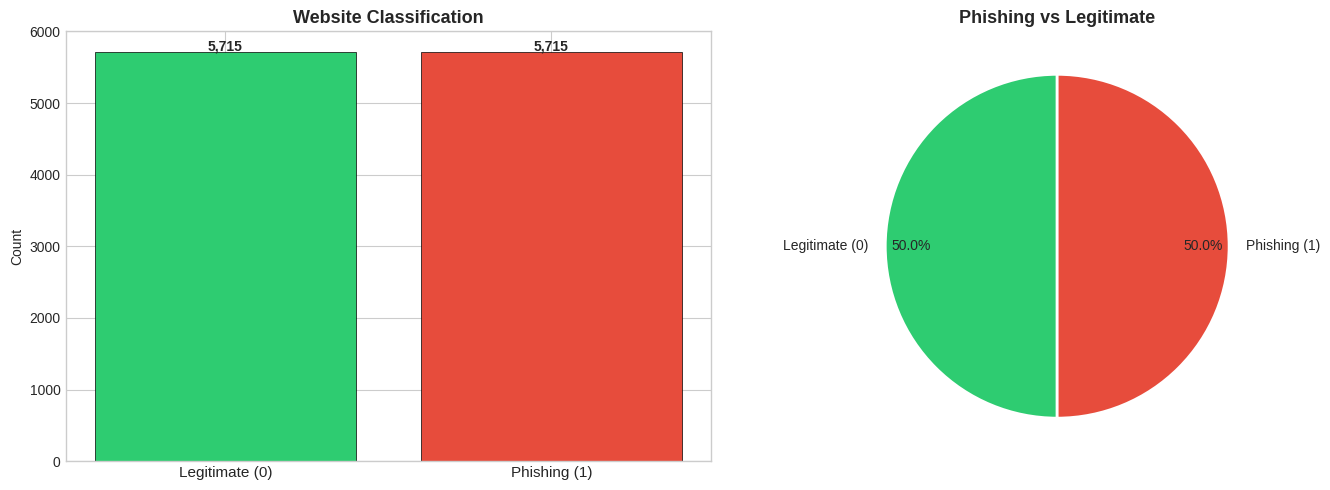

ACSC reports ~76,000 cybercrime incidents in 2022-23. Phishing is the #1 attack vector.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Legitimate (0)', 'Phishing (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))

axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Website Classification', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Phishing vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("ACSC reports ~76,000 cybercrime incidents in 2022-23. Phishing is the #1 attack vector.")


## 3. Exploratory Data Analysis

Key questions for cyber defence:
- Which URL features best distinguish phishing from legitimate?
- Are there clear thresholds (e.g., URL length, digit ratio) for rule-based pre-filters?
- How do web reputation metrics (page rank, traffic) correlate?
- Are there feature clusters that indicate phishing campaigns?


Numeric features: 87

Top 9 correlated features:
  google_index: 0.7312
  page_rank: 0.5111
  nb_www: 0.4435
  ratio_digits_url: 0.3564
  domain_in_title: 0.3428
  nb_hyperlinks: 0.3426
  phish_hints: 0.3354
  domain_age: 0.3319
  ip: 0.3217


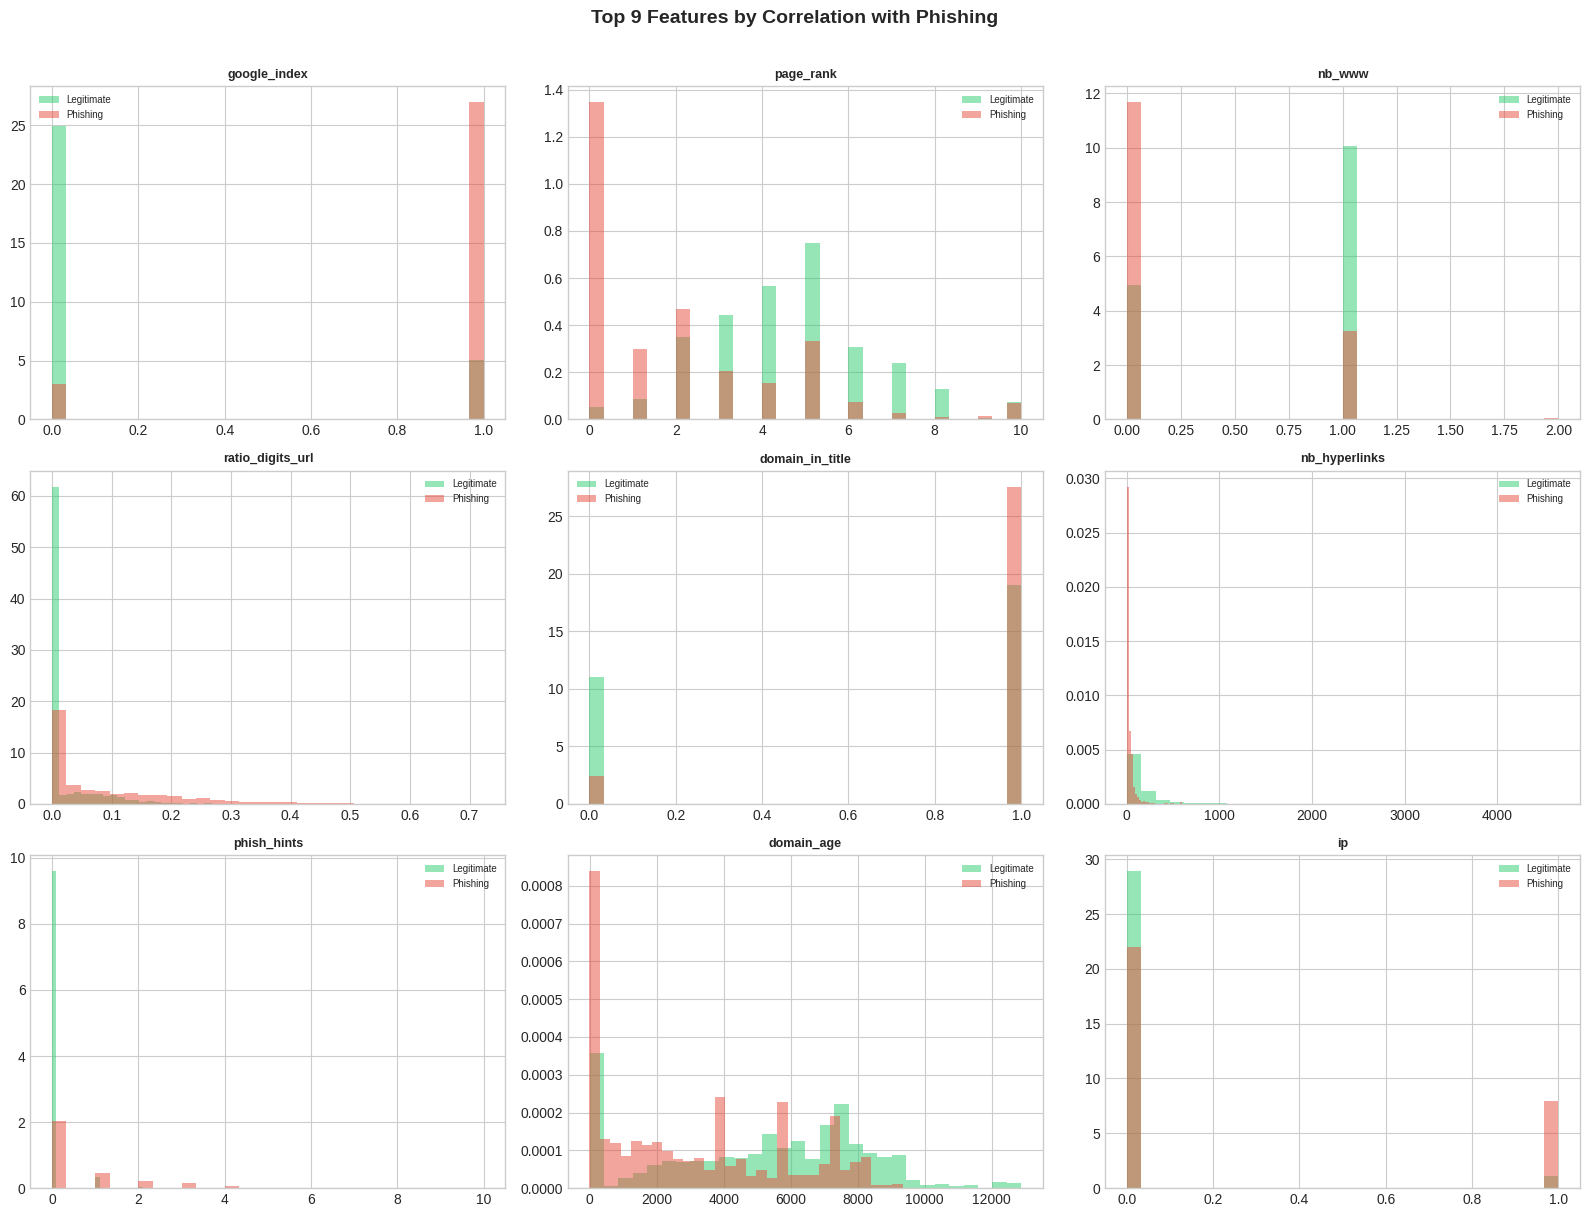

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features: {len(numeric_cols)}")

# Show top correlated features
if len(numeric_cols) > 1:
    corr_with_target = df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
    top_features = corr_with_target.head(9).index.tolist()
    print(f"\nTop 9 correlated features:")
    for f in top_features:
        print(f"  {f}: {corr_with_target[f]:.4f}")
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.flatten()
    for i, col in enumerate(top_features):
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['Legitimate', 'Phishing']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7)
    plt.suptitle('Top 9 Features by Correlation with Phishing', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


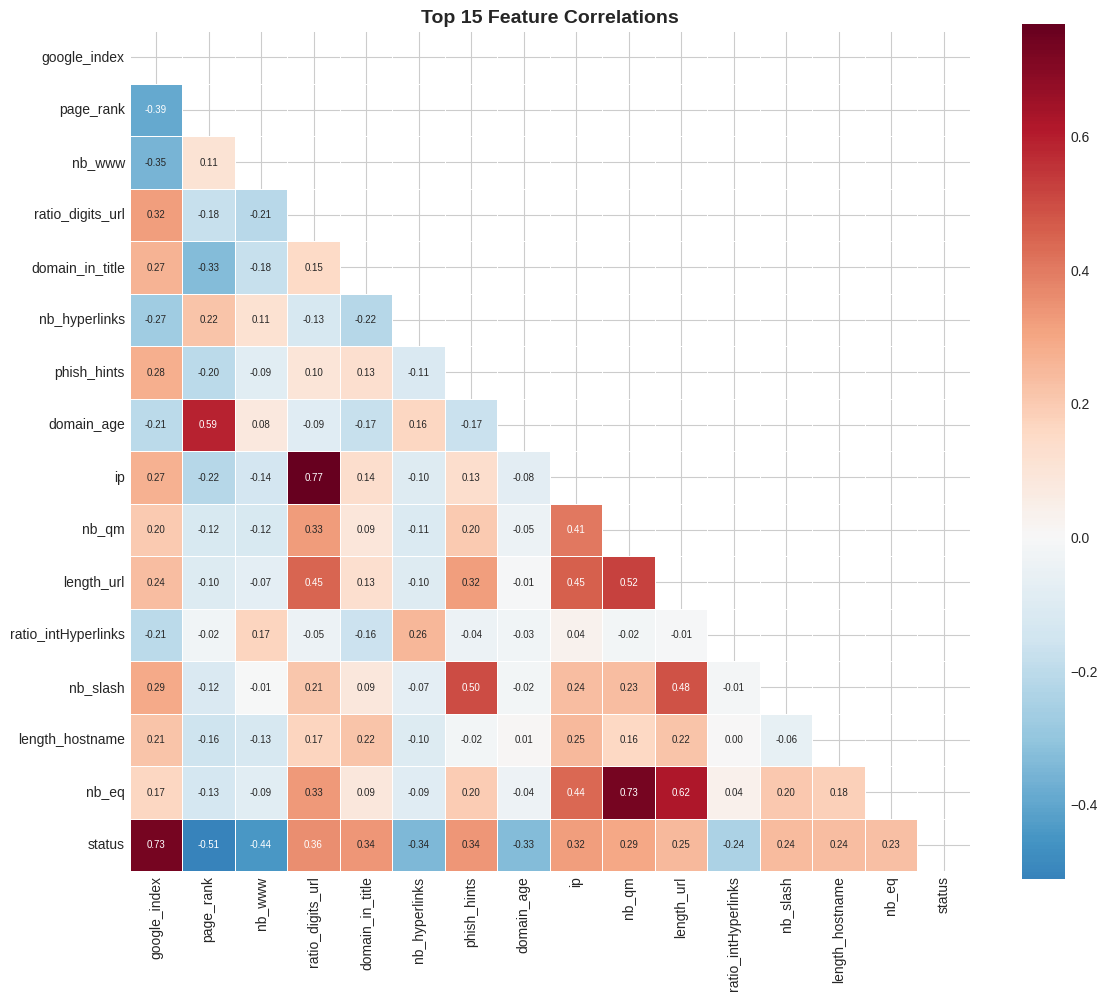

In [7]:
# Correlation heatmap (top 15 features only for readability)
if len(numeric_cols) > 1:
    top15 = corr_with_target.head(15).index.tolist()
    corr = df[top15 + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Top 15 Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

Phishing detection models benefit from:
- **URL complexity score** — combining length, digit ratio, special chars
- **Reputation composite** — page rank × web traffic × domain age
- **Suspicious indicator count** — how many individual red flags are raised


In [8]:
df_model = df.copy()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0', 'url']]
if drop_cols:
    print(f"Dropping: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")


Dropping: ['url']

Feature matrix: (11430, 87)


In [9]:
feature_names = X.columns.tolist()
composites_added = []

# URL complexity composite
url_len_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['length_url', 'url_length', 'length_hostname'])]
digit_cols = [c for c in feature_names if 'digit' in c.lower() or 'ratio' in c.lower()]
if len(url_len_cols) >= 1 and len(digit_cols) >= 1:
    X['url_complexity'] = X[url_len_cols[0]] * X[digit_cols[0]]
    composites_added.append('url_complexity')
    print(f"Created 'url_complexity'")

# Reputation composite
rank_cols = [c for c in feature_names if 'page_rank' in c.lower() or 'pagerank' in c.lower()]
traffic_cols = [c for c in feature_names if 'web_traffic' in c.lower() or 'traffic' in c.lower()]
if rank_cols and traffic_cols:
    X['reputation_score'] = X[rank_cols[0]] * X[traffic_cols[0]]
    composites_added.append('reputation_score')
    print(f"Created 'reputation_score'")

# Suspicious indicator count (sum of binary red-flag features)
binary_cols = [c for c in feature_names if X[c].nunique() == 2 and X[c].min() >= 0 and X[c].max() <= 1]
if len(binary_cols) >= 3:
    X['suspicious_count'] = X[binary_cols].sum(axis=1)
    composites_added.append('suspicious_count')
    print(f"Created 'suspicious_count' from {len(binary_cols)} binary features")

# Domain age to web traffic ratio
age_cols = [c for c in feature_names if 'domain_age' in c.lower() or 'age' in c.lower()]
if age_cols and traffic_cols:
    X['age_traffic_ratio'] = X[age_cols[0]] / (X[traffic_cols[0]] + 1e-6)
    composites_added.append('age_traffic_ratio')
    print(f"Created 'age_traffic_ratio'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'url_complexity'
Created 'reputation_score'
Created 'suspicious_count' from 31 binary features
Created 'age_traffic_ratio'

Total engineered: 4
Final feature count: 91


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.7906  F1=0.7889  AUC=0.8167
  Fold 2: Acc=0.7853  F1=0.7855  AUC=0.8205
  Fold 3: Acc=0.7827  F1=0.7804  AUC=0.8139
  -- Acc: 0.7862  F1: 0.7849  AUC: 0.8171  Time: 6.06s

Training: Random Forest
  Fold 1: Acc=0.9640  F1=0.9640  AUC=0.9921
  Fold 2: Acc=0.9567  F1=0.9568  AUC=0.9915
  Fold 3: Acc=0.9625  F1=0.9625  AUC=0.9932
  -- Acc: 0.9611  F1: 0.9611  AUC: 0.9923  Time: 2.54s

Training: XGBoost
  Fold 1: Acc=0.9646  F1=0.9646  AUC=0.9932
  Fold 2: Acc=0.9638  F1=0.9637  AUC=0.9925
  Fold 3: Acc=0.9706  F1=0.9707  AUC=0.9949
  -- Acc: 0.9663  F1: 0.9663  AUC: 0.9935  Time: 1.26s

Training: LightGBM
  Fold 1: Acc=0.9654  F1=0.9653  AUC=0.9939
  Fold 2: Acc=0.9633  F1=0.9632  AUC=0.9921
  Fold 3: Acc=0.9698  F1=0.9699  AUC=0.9947
  -- Acc: 0.9661  F1: 0.9662  AUC: 0.9936  Time: 1.36s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
           LightGBM 0.9661 +/- 0.0027 0.9662 +/- 0.0028 0.9936 +/- 0.0011 0.0260 1.36s
            XGBoost 0.9663 +/- 0.0030 0.9663 +/- 0.0031 0.9935 +/- 0.0010 0.0271 1.26s
      Random Forest 0.9611 +/- 0.0032 0.9611 +/- 0.0031 0.9923 +/- 0.0007 0.0336 2.54s
Logistic Regression 0.7862 +/- 0.0033 0.7849 +/- 0.0035 0.8171 +/- 0.0027 0.1789 6.06s

Best model: LightGBM


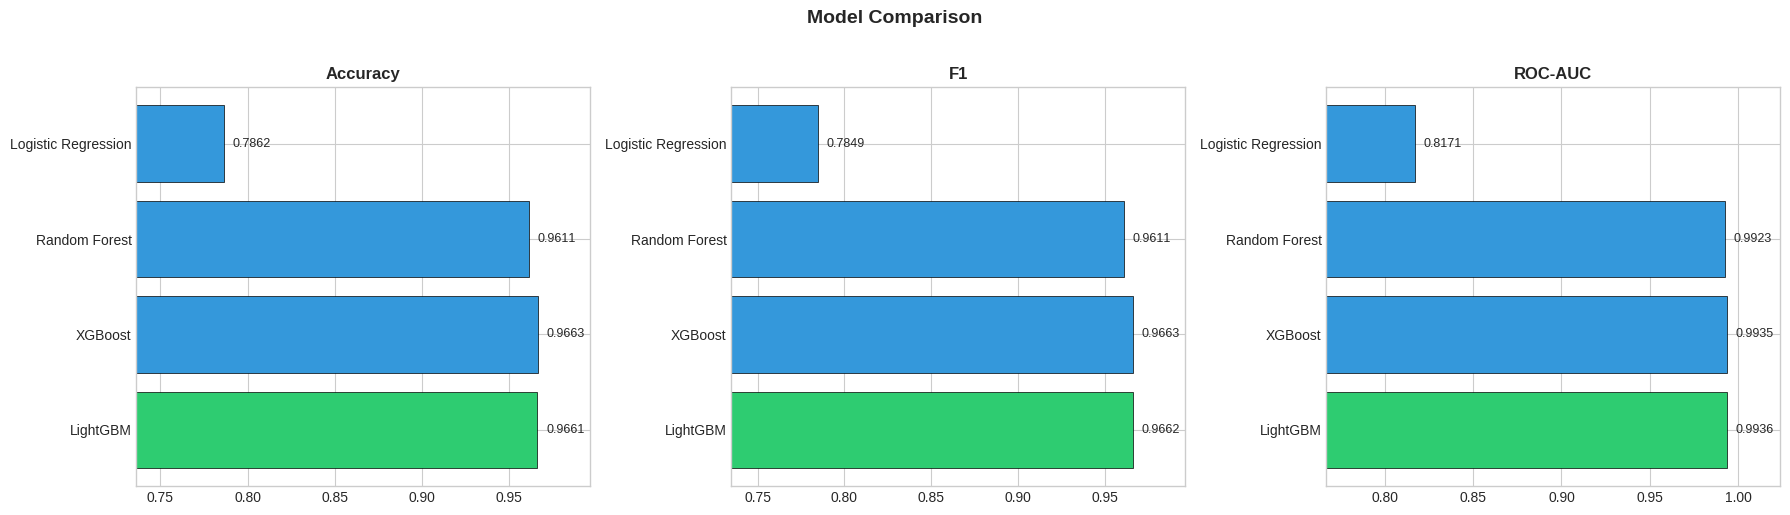

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For phishing detection:
- **False negatives** (missed phishing) = credential theft, data breaches, financial loss
- **False positives** (blocking legitimate) = user frustration, productivity loss
- Government networks should bias toward security (lower threshold)


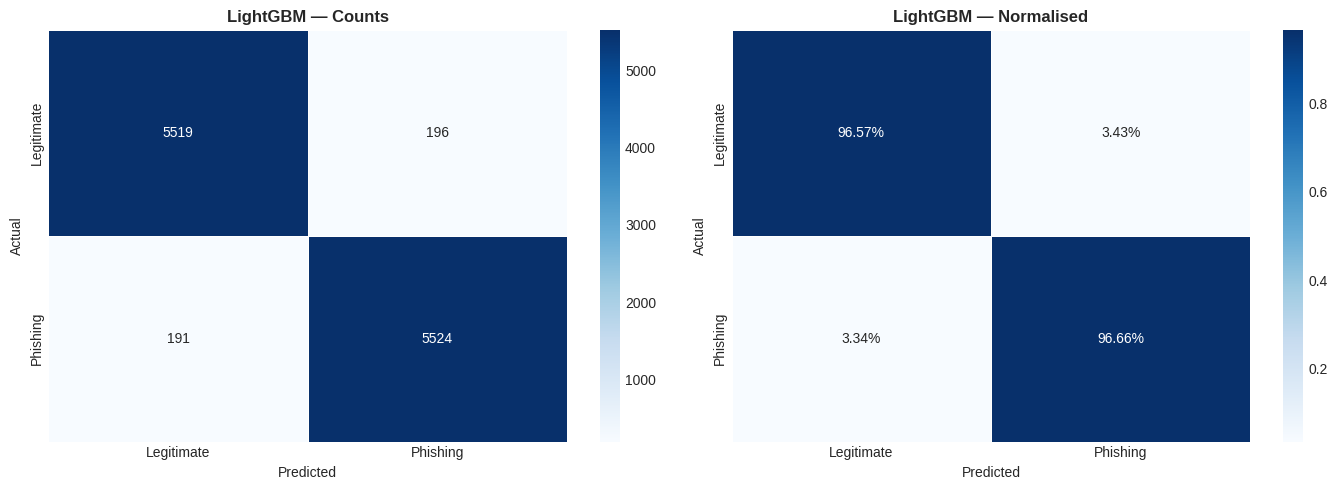


              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97      5715
    Phishing       0.97      0.97      0.97      5715

    accuracy                           0.97     11430
   macro avg       0.97      0.97      0.97     11430
weighted avg       0.97      0.97      0.97     11430



In [14]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Legitimate', 'Phishing']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


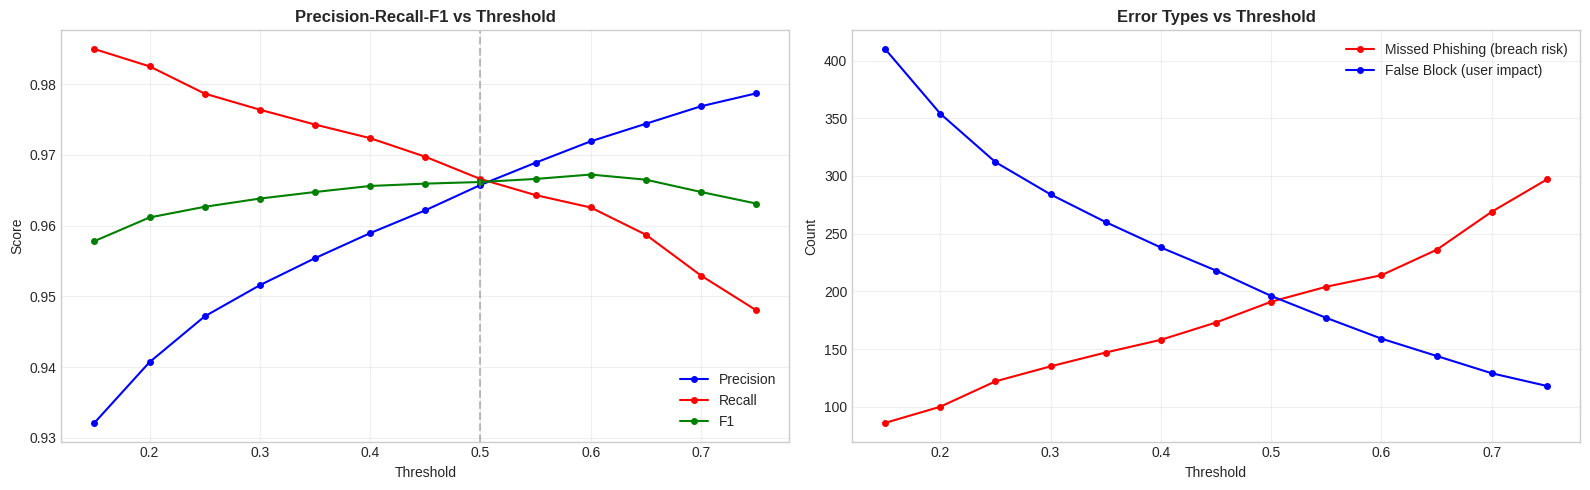


Optimal threshold (F1): 0.60
For government networks, consider lower threshold (0.30-0.40) to prioritise security.


In [15]:
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Phishing (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Block (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Phishing (FN)'], 'r-o', ms=4, label='Missed Phishing (breach risk)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Block (FP)'], 'b-o', ms=4, label='False Block (user impact)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"For government networks, consider lower threshold (0.30-0.40) to prioritise security.")


## 8. Feature Importance & Policy Insights

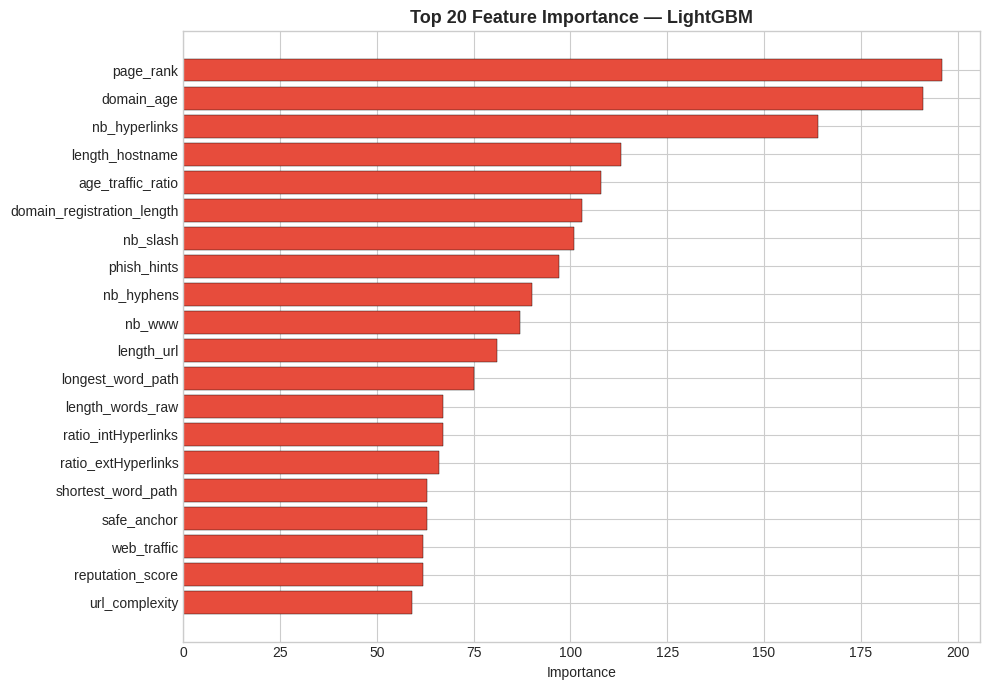

TOP 5 PREDICTIVE FEATURES
  page_rank                                 196.0000
  domain_age                                191.0000
  nb_hyperlinks                             164.0000
  length_hostname                           113.0000
  age_traffic_ratio                         108.0000


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(20)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.35)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:40s}  {row['Importance']:.4f}")


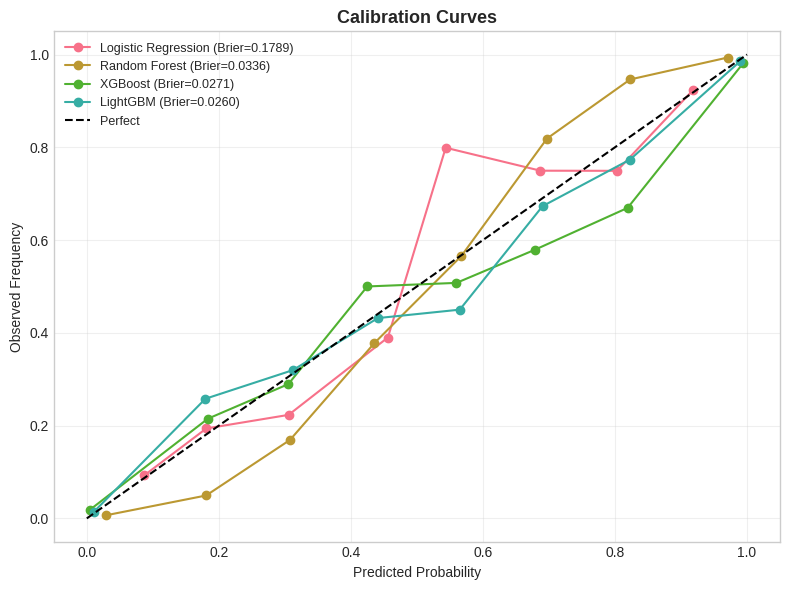

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [18]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.85': best_res['auc_mean'] > 0.85,
    'F1 > 0.80': best_res['f1_mean'] > 0.80,
    'Brier < 0.15': best_res['brier_mean'] < 0.15,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  ROC-AUC:              0.9936
  F1:                   0.9662
  Precision:            0.9657
  Recall:               0.9666
  Brier Score:          0.0260
  Training time:        1.4s
  Feature count:        91
  Dataset rows:         11,430
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.60

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.85
  [pass] F1 > 0.80
  [pass] Brier < 0.15
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [19]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Web proxy logs, DNS queries, URL submissions (ReportCyber)
   Ingestion: Real-time stream (Kafka/Event Hub) -> Fabric Lakehouse
   Feature extraction: URL parser -> feature vector in <10ms
   Threat intel: ACSC indicators, PhishTank, OpenPhish feed integration

2. MODEL SERVING
   Framework: MLflow / ONNX for low-latency inference
   Endpoint: Real-time (<50ms per URL for inline proxy decision)
   Batch: Nightly scan of bookmarks/allowlists for compromised domains
   Ensemble: ML model + rule-based blocklist + threat intel match

3. INTEGRATION POINTS
   Web proxy: Inline URL classification (Zscaler/Palo Alto/Squid)
   Email gateway: Pre-delivery phishing link scanning
   SIEM: Alert generation for SOC investigation (Splunk/Sentinel)
   Browser extension: Real-time user warning overlay
   Threat intel: Auto-submit confirmed phishing to ACSC

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> default to allowlist-only mode
   Override: SOC analysts can whitelist false positives
   Privacy: URL logging complies with Surveillance Devices Act
   Classification: Model itself may be PROTECTED (ASD guidance)
   Essential Eight: Contributes to web content filtering control

5. MONITORING & RETRAINING
   Drift: PSI on URL feature distributions daily
   Performance: F1 on SOC-confirmed classifications weekly
   Adversarial: Monitor for evasion patterns (URL obfuscation evolution)
   Retraining: Weekly with confirmed phishing/legitimate labels
   Red team: Quarterly adversarial testing of model robustness

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Web proxy logs, DNS queries, URL submissions (ReportCyber)
   Ingestion: Real-time stream (Kafka/Event Hub) -> Fabric Lakehouse
   Feature extraction: URL parser -> feature vector in <10ms
   Threat intel: ACSC indicators, PhishTank, OpenPhish feed integration

2. MODEL SERVING
   Framework: MLflow / ONNX for low-latency inference
   Endpoint: Real-time (<50ms per URL for inline proxy decision)
   Batch: Nightly scan of bookmarks/allowlists for compromised domains
   Ensemble: ML model + rule-based blocklist + threat intel match

3. INTEGRATION POINTS
   Web proxy: Inline URL classification (Zscaler/Palo Alto/Squid)
   Email gateway: Pre-delivery phishing link scanning
   SIEM: Alert generation for SOC investigation (Splunk/Sentinel)
   Browser extension: Real-time user warning overlay
   Threat intel: Auto-submit confirmed phishing to ACSC

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> default to allowlist-only m